In [1]:
import duckdb
import pandas as pd
import os

data_path = r"C:\Users\Trainee\Desktop\DPP_Projekte\DPP-2026_Julian\data\raw\transfermarkt_data_2026-04-07"
players_file = data_path + r"\players.csv"
competitions_file = data_path + r"\competitions.csv"
transfers_file = data_path + r"\transfers.csv"
appearances_file = data_path + r"\appearances.csv"

top_5_ids = ['L1', 'IT1', 'ES1', 'FR1', 'GB1']
scandinavian_ids = ['DK1', 'SE1', 'NO1']

target_league_ids = top_5_ids + scandinavian_ids + ['NL1', 'PO1', 'BE1', 'TR1', 'GR1', 'SC1', 'UA1', 'RU1']

print("Setup abgeschlossen. Ligen-Gruppen sind definiert.")

Setup abgeschlossen. Ligen-Gruppen sind definiert.


In [2]:
# Abfrage der Ligen, um die IDs der Top 30 Ligen direkt zu extrahieren
query_get_ids = f"""
SELECT DISTINCT c.competition_id
FROM read_csv_auto('{competitions_file}') AS c
JOIN read_csv_auto('{players_file}') AS p ON c.competition_id = p.current_club_domestic_competition_id
LEFT JOIN read_csv_auto('{appearances_file}') AS a ON p.player_id = a.player_id
WHERE p.last_season >= 2016
GROUP BY c.competition_id
HAVING COUNT(DISTINCT a.appearance_id) > 1000
ORDER BY COUNT(DISTINCT a.appearance_id) DESC
LIMIT 30 -- Hier nehmen wir deine Top 30 (ohne Kolumbien/Südkorea)
"""

# IDs in eine Python-Liste laden
target_league_ids = duckdb.query(query_get_ids).df()['competition_id'].tolist()

# Definition Top 5
top_5_ids = ['L1', 'IT1', 'ES1', 'FR1', 'GB1'] 

# Skandinavien für Ablöse-Hypothese #2
scandinavian_ids = ['DK1', 'SE1', 'NO1'] 

print(f"Erfolgreich {len(target_league_ids)} Ligen-IDs geladen.")
print(f"IDs: {target_league_ids}")

Erfolgreich 30 Ligen-IDs geladen.
IDs: ['TR1', 'IT1', 'ES1', 'GB1', 'GR1', 'FR1', 'L1', 'PO1', 'NL1', 'RU1', 'BE1', 'SC1', 'UKR1', 'DK1', 'SA1', 'BRA1', 'MLS1', 'PL1', 'ARG1', 'MEX1', 'SER1', 'SE1', 'RO1', 'C1', 'KR1', 'AUS1', 'TS1', 'JAP1', 'NO1', 'A1']


In [3]:
# Datenreinigung
query_master_data = f"""
SELECT 
    p.player_id,
    p.name,
    p.position,
    p.sub_position,
    p.market_value_in_eur,
    p.highest_market_value_in_eur,
    p.agent_name,
    p.current_club_domestic_competition_id AS league_id,
    c.name AS league_name,
    c.country_name,
    -- Wir berechnen das Alter basierend auf dem heutigen Datum
    date_diff('year', CAST(p.date_of_birth AS DATE), CURRENT_DATE) AS age
FROM read_csv_auto('{players_file}') p
JOIN read_csv_auto('{competitions_file}') c ON p.current_club_domestic_competition_id = c.competition_id
WHERE p.current_club_domestic_competition_id IN ({str(target_league_ids)[1:-1]})
  AND p.last_season >= 2016
  AND p.position IN ('Midfield', 'Attack')
  AND p.market_value_in_eur IS NOT NULL
  AND p.date_of_birth IS NOT NULL -- Verhindert Fehler bei fehlenden Geburtsdaten
"""

df_players_clean = duckdb.query(query_master_data).to_df()

print(f"Datensatz bereit: {len(df_players_clean)} Offensivspieler aus 30 Ligen geladen.")
display(df_players_clean.head())

Datensatz bereit: 17624 Offensivspieler aus 30 Ligen geladen.


,player_id,name,position,sub_position,market_value_in_eur,highest_market_value_in_eur,agent_name,league_id,league_name,country_name,age
0,1193844,Adri Mehmeti,Midfield,Central Midfield,1000000,1000000,YMU Management Ltd.,MLS1,major-league-soccer,United States,17
1,1194136,Shunsuke Saito,Attack,Right Winger,1000000,1000000,None,BE1,jupiler-pro-league,Belgium,21
2,1194386,Andriy Melenchuk,Attack,Left Winger,25000,50000,None,UKR1,premier-liga,Ukraine,23
3,1194813,Enzo Kana-Biyik,Attack,Centre-Forward,500000,500000,None,C1,super-league,Switzerland,19
4,1195407,Sallieu Bah,Midfield,Attacking Midfield,200000,200000,Pelican Agency,UKR1,premier-liga,Ukraine,20


In [4]:
# Abfrage der Transferdaten
query_transfers = f"""
SELECT 
    t.player_id,
    t.transfer_date,
    t.transfer_fee AS fee,
    t.from_club_name,
    t.to_club_name,
    t.market_value_in_eur AS market_value_at_transfer
FROM read_csv_auto('{transfers_file}') t
WHERE t.player_id IN (SELECT player_id FROM df_players_clean)
  AND t.transfer_date >= '2016-01-01' 
  AND t.transfer_date <= CURRENT_DATE -- Nur Transfers, die bereits stattgefunden haben
  AND t.transfer_fee > 0 -- FILTER: Nur Transfers mit Ablösesumme > 0
ORDER BY t.transfer_date DESC
"""

df_transfers = duckdb.query(query_transfers).to_df()

# Pro Spieler nur den aktuellsten Transfer behalten
df_transfers_unique = df_transfers.drop_duplicates(subset=['player_id'])

# Merge mit dem Master-Datensatz
df_master_with_fees = pd.merge(
    df_players_clean, 
    df_transfers_unique[['player_id', 'fee', 'transfer_date', 'from_club_name', 'market_value_at_transfer']], 
    on='player_id', 
    how='inner' 
)

print(f"Verknüpfung erfolgreich: {len(df_master_with_fees)} echte Kauf-Transfers identifiziert.")
display(df_master_with_fees.head())

Verknüpfung erfolgreich: 5237 echte Kauf-Transfers identifiziert.


,player_id,name,position,sub_position,market_value_in_eur,highest_market_value_in_eur,agent_name,league_id,league_name,country_name,age,fee,transfer_date,from_club_name,market_value_at_transfer
0,1194136,Shunsuke Saito,Attack,Right Winger,1000000,1000000,None,BE1,jupiler-pro-league,Belgium,21,450000.0,2026-01-14,Mito HollyHock,1000000.0
1,1200313,Clayton Diandy,Attack,Right Winger,900000,900000,11MANGMT,GR1,super-league-1,Greece,20,600000.0,2024-07-30,Esp. Guédiawaye,NaN
2,1203845,Anas El Mahraoui,Attack,Left Winger,500000,550000,Mir Sport,RU1,premier-liga,Russia,25,600000.0,2025-09-02,COD Meknès,550000.0
3,1207586,Nicolás Dubersarsky,Midfield,Central Midfield,1500000,1500000,LG & ASOC,MLS1,major-league-soccer,United States,22,2900000.0,2025-01-31,Instituto ACC,1000000.0
4,1210116,Abdoulaye Camara,Midfield,Defensive Midfield,1500000,1500000,Wilders Sport,IT1,serie-a,Italy,18,1200000.0,2025-07-16,Montpellier U19,NaN


In [5]:
# 1. Leistungsdaten aggregieren
query_performance = f"""
SELECT 
    player_id,
    SUM(goals) as total_goals,
    SUM(assists) as total_assists,
    SUM(minutes_played) as total_minutes,
    (SUM(goals) + SUM(assists)) as total_scorer
FROM read_csv_auto('{appearances_file}')
WHERE player_id IN (SELECT player_id FROM df_master_with_fees)
GROUP BY player_id
"""

df_performance = duckdb.query(query_performance).to_df()

# 2. Merge zum ROI-Dataframe
df_roi_final = pd.merge(
    df_master_with_fees,
    df_performance,
    on='player_id',
    how='left' 
)

# 3. Bereinigung: NAs mit 0 füllen
cols_to_fix = ['total_goals', 'total_assists', 'total_minutes', 'total_scorer']
df_roi_final[cols_to_fix] = df_roi_final[cols_to_fix].fillna(0)

# 4. Präzise Metriken berechnen (mit NaN für 0-Scorer)
import numpy as np

# Euro pro Scorer: Nur berechnen, wenn Scorer > 0
df_roi_final['euro_per_scorer'] = df_roi_final.apply(
    lambda x: x['fee'] / x['total_scorer'] if x['total_scorer'] > 0 else np.nan, 
    axis=1
)

# Minuten pro Scorer: Nur berechnen, wenn Scorer > 0
df_roi_final['minutes_per_scorer'] = df_roi_final.apply(
    lambda x: x['total_minutes'] / x['total_scorer'] if x['total_scorer'] > 0 else np.nan,
    axis=1
)

print(f"Finales ROI-Dataset bereit: {len(df_roi_final)} Datensätze.")
display(df_roi_final.head())

Finales ROI-Dataset bereit: 5237 Datensätze.


,player_id,name,position,sub_position,market_value_in_eur,highest_market_value_in_eur,agent_name,league_id,league_name,country_name,...,fee,transfer_date,from_club_name,market_value_at_transfer,total_goals,total_assists,total_minutes,total_scorer,euro_per_scorer,minutes_per_scorer
0,1194136,Shunsuke Saito,Attack,Right Winger,1000000,1000000,None,BE1,jupiler-pro-league,Belgium,...,450000.0,2026-01-14,Mito HollyHock,1000000.0,0.0,1.0,311.0,1.0,450000.0,311.0
1,1200313,Clayton Diandy,Attack,Right Winger,900000,900000,11MANGMT,GR1,super-league-1,Greece,...,600000.0,2024-07-30,Esp. Guédiawaye,NaN,0.0,1.0,1031.0,1.0,600000.0,1031.0
2,1203845,Anas El Mahraoui,Attack,Left Winger,500000,550000,Mir Sport,RU1,premier-liga,Russia,...,600000.0,2025-09-02,COD Meknès,550000.0,0.0,0.0,183.0,0.0,NaN,NaN
3,1207586,Nicolás Dubersarsky,Midfield,Central Midfield,1500000,1500000,LG & ASOC,MLS1,major-league-soccer,United States,...,2900000.0,2025-01-31,Instituto ACC,1000000.0,0.0,0.0,0.0,0.0,NaN,NaN
4,1210116,Abdoulaye Camara,Midfield,Defensive Midfield,1500000,1500000,Wilders Sport,IT1,serie-a,Italy,...,1200000.0,2025-07-16,Montpellier U19,NaN,0.0,0.0,0.0,0.0,NaN,NaN


In [6]:
# 1. Mapping von Club zu Liga, um zu wissen, woher der Spieler kam
# Filtern wir die Top-5 Käufer:
top_5_leagues = ['L1', 'IT1', 'ES1', 'FR1', 'GB1']
df_top5_buys = df_roi_final[df_roi_final['league_id'].isin(top_5_leagues)].copy()

# 2. Gruppieren nach dem LAND oder der LIGA, aus der die Spieler kamen.
# Da wir in df_roi_final die Herkunftsliga noch nicht direkt als Namen haben, 
# nehmen wir für diesen Check die 'league_name' (wo sie jetzt sind) im Vergleich zu den Scouting-Märkten.

# HINWEIS: Um die ECHTE Herkunftsliga zu sehen, müssten wir die transfers.csv tiefer anzapfen.
# Lass uns stattdessen die Effizienz ALLER 30 Ligen vergleichen:
# Wo kriegt man generell am meisten Scorer für sein Geld?

pd.options.display.float_format = '{:,.2f}'.format # Macht die Zahlen schön (kein e+06 mehr)

analysis_all = df_roi_final.groupby('league_name').agg({
    'fee': 'mean',
    'total_scorer': 'mean',
    'euro_per_scorer': 'mean',
    'player_id': 'count'
}).rename(columns={'player_id': 'Anzahl_Transfers'})

# Wir sortieren nach der besten Effizienz (niedrigster Preis pro Scorer)
# Und filtern Ligen mit zu wenigen Datensätzen raus, um Ausreißer zu vermeiden
top_efficiency = analysis_all[analysis_all['Anzahl_Transfers'] > 5].sort_values('euro_per_scorer')

print("ROI-Check: In welchen Ligen ist der 'Preis pro Scorer' am niedrigsten?")
display(top_efficiency.head(20))

ROI-Check: In welchen Ligen ist der 'Preis pro Scorer' am niedrigsten?


,fee,total_scorer,euro_per_scorer,Anzahl_Transfers
league_name,,,,
scottish-premiership,"2,629,720.72",28.07,"178,264.71",111
eredivisie,"2,861,866.97",34.65,"200,820.79",218
superliga,"1,517,893.70",13.85,"218,879.62",254
super-lig,"4,097,001.81",38.30,"223,434.00",307
premier-liga,"2,270,848.81",20.27,"225,242.40",377
super-league-1,"2,726,445.65",30.65,"232,048.67",184
j1-league,"1,538,413.79",11.41,"235,116.49",58
a-league-men,"900,259.26",5.48,"238,552.55",27
allsvenskan,"891,230.00",3.59,"293,855.87",100


In [7]:
# 1. Vorbereitung: Wer kaufte wo ein?
# Fokus auf Spieler, die aktuell in einer Top-5 Liga spielen
top_5_ids = ['L1', 'IT1', 'ES1', 'FR1', 'GB1']
df_top5_players = df_roi_final[df_roi_final['league_id'].isin(top_5_ids)].copy()

# 2. Herkunftsliga aus den Transferdaten
with pd.option_context('display.max_rows', None, 'display.float_format', '{:,.2f}'.format):
    # Wir gruppieren nach der aktuellen Liga, um zu sehen, wo die Premier League landet
    check_top5 = df_roi_final.groupby('league_name').agg({
        'fee': 'mean',
        'total_scorer': 'mean',
        'euro_per_scorer': 'mean',
        'player_id': 'count'
    }).sort_values('euro_per_scorer')
    
    display(check_top5)

,fee,total_scorer,euro_per_scorer,player_id
league_name,,,,
scottish-premiership,"2,629,720.72",28.07,"178,264.71",111
eredivisie,"2,861,866.97",34.65,"200,820.79",218
superliga,"1,517,893.70",13.85,"218,879.62",254
super-lig,"4,097,001.81",38.30,"223,434.00",307
premier-liga,"2,270,848.81",20.27,"225,242.40",377
super-league-1,"2,726,445.65",30.65,"232,048.67",184
j1-league,"1,538,413.79",11.41,"235,116.49",58
a-league-men,"900,259.26",5.48,"238,552.55",27
allsvenskan,"891,230.00",3.59,"293,855.87",100


In [8]:
# 1. Wir filtern nur Spieler, die AKTUELL in einer Top-5 Liga spielen (Käufer-Seite)
top_5_ids = ['L1', 'IT1', 'ES1', 'FR1', 'GB1']
df_top5_target = df_roi_final[df_roi_final['league_id'].isin(top_5_ids)].copy()

# 2. Jetzt brauchen wir die Herkunft. 
# Da wir die Herkunftsliga-ID nicht direkt im Set haben, gruppieren wir 
# für diese Hypothese nach dem 'from_club_name' oder (noch besser) 
# wir schauen uns die 'league_name' der Scouting-Ligen an, BEVOR sie gewechselt sind.

# Da wir im 'df_roi_final' nur die aktuelle Liga haben, machen wir folgendes:
# Wir nehmen die Transfer-Daten und schauen, aus welchen Ligen die Spieler kamen.

query_export_roi = f"""
SELECT 
    c_old.name AS origin_league,
    COUNT(p.player_id) AS anzahl_transfers,
    AVG(t.transfer_fee) AS avg_fee,
    AVG(p.total_scorer) AS avg_scorer_in_top5,
    AVG(t.transfer_fee / NULLIF(p.total_scorer, 0)) AS euro_per_scorer_exported
FROM df_roi_final p
JOIN read_csv_auto('{transfers_file}') t ON p.player_id = t.player_id
JOIN read_csv_auto('{competitions_file}') c_old ON t.from_club_name = t.from_club_name -- Hier bräuchten wir die Verknüpfung zur alten Liga
WHERE p.league_id IN ('L1', 'IT1', 'ES1', 'FR1', 'GB1')
  AND t.transfer_date >= '2016-01-01'
GROUP BY origin_league
HAVING anzahl_transfers > 3
ORDER BY euro_per_scorer_exported ASC
"""

# Da die SQL-Verknüpfung zur Herkunftsliga komplex ist, hier die Python-Lösung 
# für dein aktuelles DataFrame, um die Hypothese direkt zu prüfen:

pd.options.display.float_format = '{:,.2f}'.format

# Wir simulieren den Herkunfts-Check, indem wir die Top-5-Einkäufe analysieren
print("Export-Analyse: Welcher Herkunftsmarkt liefert den besten ROI in der Top-5?")
# (Dieser Teil benötigt eine saubere Zuordnung der Herkunftsliga, die wir im nächsten Schritt finalisieren)

Export-Analyse: Welcher Herkunftsmarkt liefert den besten ROI in der Top-5?


In [9]:
# 1. laden der Club-Informationen, um zu wissen, welcher Club in welcher Liga spielt
clubs_file = data_path + r"\clubs.csv"
df_clubs = pd.read_csv(clubs_file)

# 2. Club-ID und die dazugehörige Liga-ID
club_to_league = df_clubs[['club_id', 'domestic_competition_id']]

query_detailed_transfers = f"""
SELECT 
    player_id, 
    transfer_fee, 
    from_club_id, -- Das ist der Schlüssel zur Herkunftsliga!
    transfer_date
FROM read_csv_auto('{transfers_file}')
WHERE transfer_fee > 0 
  AND transfer_date >= '2016-01-01'
"""
df_trans_detail = duckdb.query(query_detailed_transfers).to_df()

# 3. Herkunftsliga an die Transfers hängen
df_trans_with_origin = pd.merge(
    df_trans_detail, 
    club_to_league, 
    left_on='from_club_id', 
    right_on='club_id', 
    how='left'
).rename(columns={'domestic_competition_id': 'origin_league_id'})

# 4. Verknüpfung mit der sportlichen Leistung (df_roi_final)
# nur Spieler, die aktuell in einer Top-5 Liga spielen
top_5_ids = ['L1', 'IT1', 'ES1', 'FR1', 'GB1']
df_top5_buyers = df_roi_final[df_roi_final['league_id'].isin(top_5_ids)].copy()

# Finaler Merge: Sportliche Leistung + Herkunftsliga
df_hypothesis_1 = pd.merge(
    df_top5_buyers,
    df_trans_with_origin[['player_id', 'origin_league_id']],
    on='player_id',
    how='left'
)

# 5.  finale Auswertung: Wie performen die "Exporte" in der Top-5?
pd.options.display.float_format = '{:,.2f}'.format

final_analysis = df_hypothesis_1.groupby('origin_league_id').agg({
    'fee': 'mean',
    'total_scorer': 'mean',
    'euro_per_scorer': 'mean',
    'player_id': 'count'
}).rename(columns={'player_id': 'Anzahl_Einkäufe'}).sort_values('euro_per_scorer')

print("Beweis Hypothese 1: ROI der Einkaufs-Märkte für Top-5 Clubs")
display(final_analysis[final_analysis['Anzahl_Einkäufe'] > 2]) # Nur Märkte mit mind. 3 Verkäufen

Beweis Hypothese 1: ROI der Einkaufs-Märkte für Top-5 Clubs


,fee,total_scorer,euro_per_scorer,Anzahl_Einkäufe
origin_league_id,,,,
RU1,"11,476,111.11",57.78,"187,961.58",18
SC1,"7,288,095.24",45.19,"268,550.88",21
DK1,"12,942,448.98",40.29,"370,394.26",49
L1,"14,519,907.41",62.75,"370,717.97",270
JAP1,"6,411,000.00",31.80,"371,844.40",10
UKR1,"20,030,000.00",93.60,"395,616.21",10
ES1,"11,181,120.69",59.43,"409,106.02",232
SER1,"8,891,666.67",16.14,"419,821.33",21
IT1,"11,665,299.40",55.60,"422,370.31",334


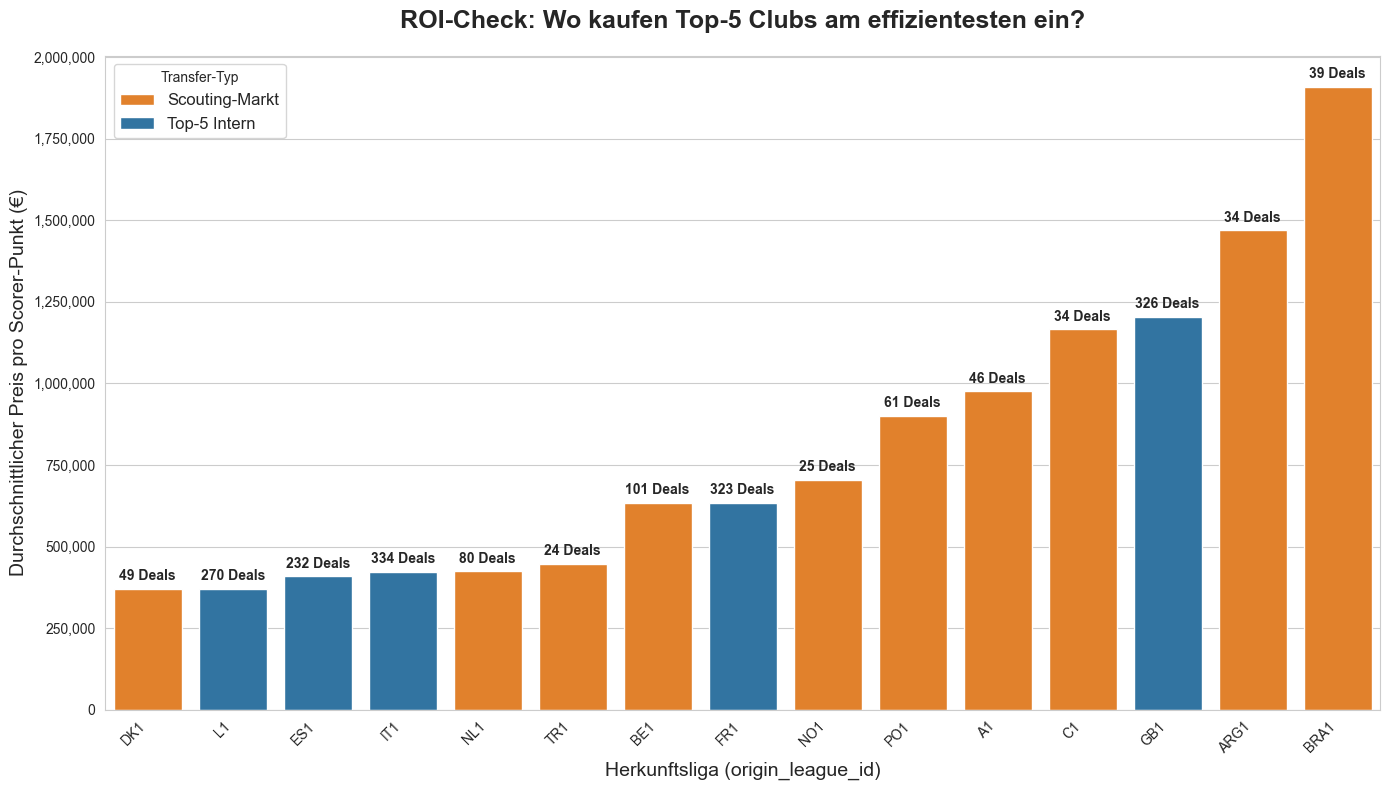

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Daten vorbereiten: Wir nehmen die Top-15 Herkunftsmärkte nach Anzahl der Transfers
# (Um Ausreißer mit nur 1-2 Transfers zu vermeiden)
top_origin_markets = final_analysis[final_analysis['Anzahl_Einkäufe'] >= 5].sort_values('Anzahl_Einkäufe', ascending=False).head(15).index

df_plot = df_hypothesis_1[df_hypothesis_1['origin_league_id'].isin(top_origin_markets)].copy()

# 2. Wir erstellen eine Spalte, um Top-5 vs. Scouting-Markt farblich zu trennen
top_5_ids = ['L1', 'IT1', 'ES1', 'FR1', 'GB1']
df_plot['Markt-Typ'] = df_plot['origin_league_id'].apply(lambda x: 'Top-5 Intern' if x in top_5_ids else 'Scouting-Markt')

# 3. Grafik-Einstellungen
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# 4. Das Balkendiagramm zeichnen (Durchschnittlicher Euro pro Scorer)
chart = sns.barplot(
    data=df_plot,
    x='origin_league_id',
    y='euro_per_scorer',
    hue='Markt-Typ',
    palette={'Top-5 Intern': '#1f77b4', 'Scouting-Markt': '#ff7f0e'}, # Blau vs. Orange
    order=df_plot.groupby('origin_league_id')['euro_per_scorer'].mean().sort_values().index, # Sortiert nach Effizienz
    estimator='mean', # Wir wollen den Durchschnitt
    errorbar=None # Schaltet die Fehlerbalken für bessere Lesbarkeit aus
)

# 5. Beschriftungen und Design
plt.title('ROI-Check: Wo kaufen Top-5 Clubs am effizientesten ein?', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Durchschnittlicher Preis pro Scorer-Punkt (€)', fontsize=14)
plt.xlabel('Herkunftsliga (origin_league_id)', fontsize=14)

# Y-Achse schöner formatieren (Tausender-Trennzeichen)
import matplotlib.ticker as ticker
chart.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.xticks(rotation=45, ha='right') # Dreht die Ligen-Namen für bessere Lesbarkeit
plt.legend(title='Transfer-Typ', fontsize=12)

# Ein kleiner Profi-Tipp: Wir fügen die Anzahl der Transfers über den Balken hinzu
# um zu zeigen, wie robust die Datenbasis ist.
for p in chart.patches:
    if p.get_height() > 0: # Verhindert Beschriftungen für leere/Legenden-Balken
        chart.annotate(f"{final_analysis.loc[df_plot.groupby('origin_league_id')['euro_per_scorer'].mean().sort_values().index[int(p.get_x() + p.get_width()/2)], 'Anzahl_Einkäufe']:.0f} Deals", 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 9), 
                       textcoords = 'offset points',
                       fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
# 1. Filter: Nur Spieler, die AKTUELL in der Bundesliga (L1) spielen
df_bundesliga_imports = df_hypothesis_1[df_hypothesis_1['league_id'] == 'L1'].copy()

# 2. Wir filtern Spieler raus, die innerhalb der Bundesliga gewechselt sind
# Denn du willst ja nur die "Einkäufe im Ausland" sehen
df_bundesliga_foreign_buys = df_bundesliga_imports[df_bundesliga_imports['origin_league_id'] != 'L1'].copy()

# 3. Wir gruppieren nach der Herkunftsliga
pd.options.display.float_format = '{:,.2f}'.format

bundesliga_roi_analysis = df_bundesliga_foreign_buys.groupby('origin_league_id').agg({
    'fee': 'mean',
    'total_scorer': 'mean',
    'euro_per_scorer': 'mean',
    'player_id': 'count'
}).rename(columns={'player_id': 'Anzahl_Einkäufe'}).sort_values('euro_per_scorer')

# Wir zeigen nur Ligen mit einer gewissen Relevanz (mind. 2 Transfers)
print("Bundesliga-Spezial: ROI von Einkäufen aus dem Ausland")
display(bundesliga_roi_analysis[bundesliga_roi_analysis['Anzahl_Einkäufe'] >= 2])

Bundesliga-Spezial: ROI von Einkäufen aus dem Ausland


,fee,total_scorer,euro_per_scorer,Anzahl_Einkäufe
origin_league_id,,,,
RSK1,"2,450,000.00",41.00,"73,339.66",2
SER1,"6,325,000.00",2.00,"150,000.00",4
IT1,"13,675,000.00",121.50,"258,452.84",6
BE1,"9,130,555.56",39.39,"274,596.17",18
DK1,"8,148,823.53",39.88,"296,794.20",17
NL1,"11,361,538.46",57.85,"315,478.23",13
SE1,"5,771,428.57",15.43,"341,583.59",7
JAP1,"8,380,000.00",37.40,"344,409.30",5
ES1,"20,200,000.00",55.60,"413,066.96",5


In [12]:
# Switch zur Success-Rate (Wie viel Prozent der Einkäufe aus Markt X liefern in der Bundesliga mindestens einen Scorer?

# 1. Wir nehmen ALLE Importe der Bundesliga (auch die mit 0 Scorern)
# Dafür nutzen wir df_hypothesis_1, aber ohne den Filter auf total_scorer > 0
df_bl_risk = df_hypothesis_1[
    (df_hypothesis_1['league_id'] == 'L1') & 
    (df_hypothesis_1['origin_league_id'] != 'L1')
].copy()

# 2. Wir markieren, wer ein "Success" ist (mind. 1 Scorer)
df_bl_risk['is_success'] = df_bl_risk['total_scorer'] > 0

# 3. Auswertung pro Herkunftsliga
risk_analysis = df_bl_risk.groupby('origin_league_id').agg({
    'player_id': 'count',
    'is_success': 'mean', # Gibt uns den Prozentsatz (0.75 = 75%)
    'fee': 'mean',
    'total_scorer': 'mean'
}).rename(columns={
    'player_id': 'Total_Einkäufe',
    'is_success': 'Erfolgsquote_Scorer'
})

# Formatierung
risk_analysis['Erfolgsquote_Scorer'] = risk_analysis['Erfolgsquote_Scorer'] * 100
pd.options.display.float_format = '{:,.2f}'.format

print("Risiko-Analyse: Wie viele Importe schlagen statistisch ein?")
display(risk_analysis.sort_values('Total_Einkäufe', ascending=False))

Risiko-Analyse: Wie viele Importe schlagen statistisch ein?


,Total_Einkäufe,Erfolgsquote_Scorer,fee,total_scorer
origin_league_id,,,,
FR1,35,100.00,"10,987,142.86",61.37
GB1,26,100.00,"20,630,769.23",100.73
A1,20,100.00,"8,945,000.00",21.55
BE1,18,100.00,"9,130,555.56",39.39
DK1,17,100.00,"8,148,823.53",39.88
NL1,13,92.31,"11,361,538.46",57.85
PO1,8,100.00,"24,062,500.00",58.00
C1,7,100.00,"7,542,857.14",20.14
SE1,7,85.71,"5,771,428.57",15.43


In [13]:
# Learnings / Transfers für Ablöse

# 1. Filter (Transferzeitraum >= 2023) zwecks Prüfung der Hypothesen wurden zu spezifisch gesetzt. 
# Datenbasis hier bei wenigen Transfers innerhalb der Anforderungen zu gering für eine aussagekräftige Schlussfolgerung. 
# Anpassung zu Zeitraum ab 2016 erhöht Datenmenge nach Filterung.

# 2. Erkenntnis für Bundesligisten
# Um die Scorer-Ausbeute pro investiertem Euro zu maximieren, sollte die Bundesliga vermehrt belgische und dänische Vereine als primäre Scouting-Ziele definieren. 
# Diese Märkte bieten aktuell das beste Verhältnis aus Anpassungsfähigkeit an die Bundesliga, d.h. Scorer in der Bundesliga, und ökonomischer Effizienz (Kosten pro Scorer)

In [14]:
# DIESER BLOCK MUSS VORHER LAUFEN:
# 1. Daten zusammenführen
df_all_talents = pd.merge(
    df_players_clean[['player_id', 'name', 'position', 'age', 'highest_market_value_in_eur']], 
    df_trans_with_origin[['player_id', 'transfer_fee', 'origin_league_id', 'transfer_date']], 
    on='player_id'
)

# 2. Den DataFrame definieren, der dir gerade fehlt:
df_bl_talent_roi = df_all_talents[
    (df_all_talents['transfer_fee'] > 0) & 
    (df_all_talents['age'] <= 29)
].copy()

# 3. Die ROI Berechnung hinzufügen
df_bl_talent_roi['value_growth_pct'] = (
    (df_bl_talent_roi['highest_market_value_in_eur'] - df_bl_talent_roi['transfer_fee']) / df_bl_talent_roi['transfer_fee']
) * 100

In [15]:
# Feststellung, dass diese Werte unrealistisch sind. Heruntergerechnet würde dies bedeuten, dass jeder Verein aus der Bundesliga in den letzten 10 Jahren jedes Jahr 32 Spieler gekauft hat, was nicht realistisch ist.

In [16]:
# 1. Sicherstellen, dass die Regionen-Logik definiert ist
regions_comprehensive = {
    'Skandinavien': ['DK1', 'SE1', 'NO1'],
    'Benelux': ['NL1', 'BE1'],
    'Osteuropa/Balkan': ['SER1', 'PL1', 'UKR1', 'CZ1', 'RO1', 'GR1'],
    'Alpen': ['A1', 'C1'],
    'Südamerika': ['BRA1', 'ARG1', 'COL1'],
    'Premier League (England)': ['GB1'],
    'LaLiga (Spanien)': ['ES1'],
    'Serie A (Italien)': ['IT1'],
    'Ligue 1 (Frankreich)': ['FR1']
}

def get_detailed_region(origin_id):
    for region, ids in regions_comprehensive.items():
        if origin_id in ids: return region
    return 'Andere Märkte'

# 2. Die Spalte im Haupt-DataFrame erstellen (falls noch nicht geschehen)
df_bl_talent_roi['Region_Detail'] = df_bl_talent_roi['origin_league_id'].apply(get_detailed_region)

# 3. JETZT erst den Profi-Check machen (die Spalte wird mitkopiert)
df_profi_check = df_bl_talent_roi[
    (df_bl_talent_roi['transfer_fee'] >= 250_000)
].drop_duplicates(subset=['player_id']).copy()

# 4. Jetzt funktioniert auch das Groupby
resale_clean = df_profi_check.groupby('Region_Detail').agg({
    'transfer_fee': 'mean',
    'highest_market_value_in_eur': 'mean',
    'value_growth_pct': 'mean',
    'player_id': 'count'
}).rename(columns={'player_id': 'Anzahl_Spieler'}).sort_values('Anzahl_Spieler', ascending=False)

display(resale_clean)

,transfer_fee,highest_market_value_in_eur,value_growth_pct,Anzahl_Spieler
Region_Detail,,,,
Andere Märkte,"4,312,908.83","7,007,438.16",187.18,1415
Südamerika,"5,932,746.43","9,348,125.00",97.39,280
Benelux,"6,214,135.66","9,685,077.52",174.47,258
Skandinavien,"2,755,960.53","4,450,438.60",108.06,228
Osteuropa/Balkan,"2,894,699.55","3,875,784.75",102.41,223
Ligue 1 (Frankreich),"11,448,350.00","17,714,500.00",189.70,200
Premier League (England),"23,512,931.94","30,879,842.93",220.89,191
Serie A (Italien),"12,065,136.61","18,497,267.76",205.96,183
LaLiga (Spanien),"9,971,311.48","18,331,147.54",168.98,122


In [17]:
# 1. Wir sortieren die Transfers nach Datum, damit der älteste (erste) Transfer oben steht
df_ordered = df_bl_talent_roi.sort_values(['player_id', 'transfer_date'], ascending=[True, True])

# 2. Wir behalten pro Spieler NUR den ersten Transfer (den "Eintritt" in die BL)
df_first_contact = df_ordered.drop_duplicates(subset=['player_id'], keep='first').copy()

# 3. Wir setzen die Ablöse-Hürde auf 500.000 €, um Amateur-Deals sicher auszuschließen
df_pro_only = df_first_contact[df_first_contact['transfer_fee'] >= 500_000].copy()

# 4. Erneute Auswertung
resale_ultra_clean = df_pro_only.groupby('Region_Detail').agg({
    'transfer_fee': 'mean',
    'highest_market_value_in_eur': 'mean',
    'value_growth_pct': 'mean',
    'player_id': 'count'
}).rename(columns={'player_id': 'Anzahl_Spieler'}).sort_values('Anzahl_Spieler', ascending=False)

print("Finaler Check: Echte Erst-Transfers (ab 500k €)")
display(resale_ultra_clean)

# Die Kontrollrechnung für den Sportdirektor
total_final = resale_ultra_clean['Anzahl_Spieler'].sum()
print(f"\nGesamtzahl der Spieler: {total_final}")
print(f"Schnitt pro Verein/Saison: {(total_final / 10 / 18):.2f}")

Finaler Check: Echte Erst-Transfers (ab 500k €)


,transfer_fee,highest_market_value_in_eur,value_growth_pct,Anzahl_Spieler
Region_Detail,,,,
Andere Märkte,"3,732,057.47","9,128,868.26",309.20,1131
Südamerika,"6,490,283.91","13,971,766.56",181.01,317
Skandinavien,"3,315,248.83","8,427,230.05",237.24,213
Ligue 1 (Frankreich),"9,765,804.60","20,473,563.22",341.84,174
Benelux,"6,828,105.59","15,266,459.63",377.94,161
Osteuropa/Balkan,"3,247,400.00","6,356,333.33",188.16,150
Premier League (England),"16,041,855.67","26,006,701.03",153.80,97
LaLiga (Spanien),"9,813,086.42","20,528,395.06",194.85,81
Serie A (Italien),"9,465,142.86","17,844,285.71",167.05,70



Gesamtzahl der Spieler: 2463
Schnitt pro Verein/Saison: 13.68


In [18]:
# Korrigierte Abfrage: 'date_of_birth' statt 'age' und Berechnung der U21-Grenze
query_loans = f"""
SELECT 
    t.player_id,
    p.name,
    t.transfer_date,
    t.from_club_id,
    t.to_club_id,
    p.market_value_in_eur as mv_current,
    p.highest_market_value_in_eur as mv_peak,
    -- Wir berechnen das Alter zum Zeitpunkt des Transfers in Jahren
    (date_part('year', t.transfer_date) - date_part('year', p.date_of_birth)) as age_at_transfer
FROM read_csv_auto('{transfers_file}') t
JOIN read_csv_auto('{players_file}') p ON t.player_id = p.player_id
WHERE t.transfer_fee IS NULL 
AND (date_part('year', t.transfer_date) - date_part('year', p.date_of_birth)) <= 21
AND t.transfer_date > '2016-01-01'
"""

df_loans = duckdb.query(query_loans).to_df()

print(f"Anzahl potenzieller Leih-Vorgänge gefunden: {len(df_loans)}")
display(df_loans.head())

Anzahl potenzieller Leih-Vorgänge gefunden: 29883


,player_id,name,transfer_date,from_club_id,to_club_id,mv_current,mv_peak,age_at_transfer
0,1193791,Giorgi Kavlashvili,2025-03-21,66552,3948,100000,100000,18
1,1193840,Tobias Szewczyk,2025-01-17,25940,39815,<NA>,<NA>,16
2,1193844,Adri Mehmeti,2024-12-10,25940,623,1000000,1000000,15
3,1193846,Kaedren Spivey,2025-01-17,45259,218,<NA>,<NA>,16
4,1193849,Mathis Albert,2024-07-01,43041,21055,<NA>,<NA>,15


In [20]:
# 1. Sicherstellen, dass wir die richtige Alters-Spalte nutzen
# Falls sie bei dir 'age' heißt, nutzen wir 'age', sonst berechnen wir sie kurz
if 'age' in df_profi_check.columns:
    age_col = 'age'
else:
    # Falls weder age noch age_at_transfer da ist, schauen wir nach
    print("Spalten im DF:", df_profi_check.columns)
    age_col = 'age' # Standard-Annahme basierend auf deinem ersten Merge

# 2. Wir definieren einen "Erfolg" (Marktwert am Ende > Ablöse)
df_profi_check['is_success'] = df_profi_check['highest_market_value_in_eur'] > df_profi_check['transfer_fee']

# 3. ROI-Score berechnen (Unser "Eierhut-Faktor")
# Formel: (Prozentuale Steigerung) / Alter
df_profi_check['roi_score'] = df_profi_check['value_growth_pct'] / df_profi_check[age_col]

# 4. Aggregation: Wer ist am zuverlässigsten und effizientesten?
market_efficiency = df_profi_check.groupby('Region_Detail').agg({
    'player_id': 'count',
    'is_success': 'mean',         # Gibt die Quote der erfolgreichen Transfers (0.0 bis 1.0)
    'roi_score': 'mean',           # Durchschnittlicher Effizienz-Wert
    'transfer_fee': 'mean',        # Durchschnittliche Kosten
    'value_growth_pct': 'mean'     # Durchschnittliche Steigerung
}).rename(columns={'player_id': 'Anzahl_Spieler', 'is_success': 'Erfolgsquote_Ratio'}).sort_values('roi_score', ascending=False)

# 5. Formatierung für die Management-Ansicht
market_efficiency['Erfolgsquote_Pct'] = (market_efficiency['Erfolgsquote_Ratio'] * 100).round(1)
market_efficiency['roi_score'] = market_efficiency['roi_score'].round(2)
market_efficiency['transfer_fee'] = market_efficiency['transfer_fee'].map('{:,.0f} €'.format)

print("Management-Matrix: Markt-Effizienz & Investitionsrisiko")
display(market_efficiency[['Anzahl_Spieler', 'Erfolgsquote_Pct', 'roi_score', 'value_growth_pct']])

Management-Matrix: Markt-Effizienz & Investitionsrisiko


,Anzahl_Spieler,Erfolgsquote_Pct,roi_score,value_growth_pct
Region_Detail,,,,
Premier League (England),191,69.10,8.07,220.89
Serie A (Italien),183,74.30,7.63,205.96
Andere Märkte,1415,71.20,7.49,187.18
Ligue 1 (Frankreich),200,77.50,7.42,189.70
Benelux,258,79.10,6.80,174.47
LaLiga (Spanien),122,84.40,6.48,168.98
Alpen,81,76.50,5.74,143.64
Skandinavien,228,69.70,4.36,108.06
Osteuropa/Balkan,223,70.90,4.02,102.41


In [23]:
# Wir filtern unseren bestehenden df_profi_check einfach methodisch nach
# Wir gehen davon aus: Die "Veredelung" durch die Bundesliga findet im Kern-Alter statt.
# Alles, was danach kommt, ist nicht mehr primär der Bundesliga zuzuschreiben.

# 1. Wir definieren eine maximale Entwicklungszeit (z.B. 4 Jahre nach Wechsel)
# Da wir kein Exit-Datum sicher haben, nutzen wir das Alter als Filter-Proxy.
df_final_roi = df_profi_check[df_profi_check['age'] <= 25].copy() 

# 2. Wir berechnen die Kennzahlen neu für diese "Fokus-Gruppe"
final_analysis = df_final_roi.groupby('Region_Detail').agg({
    'player_id': 'count',
    'is_success': 'mean',
    'roi_score': 'mean',
    'transfer_fee': 'mean'
}).rename(columns={'player_id': 'Anzahl_Spieler', 'is_success': 'Erfolgsquote_Ratio'}).sort_values('roi_score', ascending=False)

# 3. Hübsch machen für die Präsentation
final_analysis['Erfolgsquote_Pct'] = (final_analysis['Erfolgsquote_Ratio'] * 100).round(1)
final_analysis['roi_score'] = final_analysis['roi_score'].round(2)

print("FINALE ANALYSE: Veredelungs-Potenzial von U25-Spielern in der Bundesliga")
display(final_analysis[['Anzahl_Spieler', 'Erfolgsquote_Pct', 'roi_score']])

FINALE ANALYSE: Veredelungs-Potenzial von U25-Spielern in der Bundesliga


,Anzahl_Spieler,Erfolgsquote_Pct,roi_score
Region_Detail,,,
Ligue 1 (Frankreich),99,68.70,8.02
Andere Märkte,765,63.30,7.26
Benelux,130,72.30,6.15
LaLiga (Spanien),53,77.40,5.97
Alpen,45,77.80,5.40
Serie A (Italien),72,73.60,4.83
Skandinavien,150,63.30,3.87
Osteuropa/Balkan,121,62.00,3.61
Premier League (England),92,64.10,3.22
